In [1]:
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data mining, preparing data....

In [2]:
### DATAS (OMNI)....
cols_omni=["YEAR","DOY","Hour","Scalar B, nT","BX, nT (GSE)","BY, nT (GSE)","BZ, nT (GSE)",
           "SW Plasma Temperature, K","SW Proton Density, N/cm3","SW Plasma Speed, kms",
           "Kp index","Dst-index, nT","f10.7_index"]
omni=pd.read_csv("datas/omni2_pQQk5_j0p3.lst.txt",names=cols_omni,delimiter="\s+")
# 1. Combine Year and DOY into a string (e.g., 2023001)
# 2. Parse using %Y (year) and %j (day of year)
# 3. Add the hours
omni['datetime'] = pd.to_datetime(omni['YEAR'].astype(str) + omni['DOY'].astype(str).str.zfill(3), format='%Y%j') + \
                   pd.to_timedelta(omni['Hour'], unit='h')
omni.set_index("datetime",inplace=True)
omni=omni.drop(columns=["YEAR","DOY","Hour"])
# List the columns you want to clean
cols_to_fix = omni.columns
# Replace multiple flags with NaN at once
omni[cols_to_fix] = omni[cols_to_fix].replace([999.9, 9.999999E6, 9999.0, 90.0], np.nan)
omni_clean=omni.copy()

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_126329/2080337505.py:5: SyntaxWarning: invalid escape sequence '\s'
  omni=pd.read_csv("datas/omni2_pQQk5_j0p3.lst.txt",names=cols_omni,delimiter="\s+")


In [3]:
omni.head()

,"Scalar B, nT","BX, nT (GSE)","BY, nT (GSE)","BZ, nT (GSE)","SW Plasma Temperature, K","SW Proton Density, N/cm3","SW Plasma Speed, kms",Kp index,"Dst-index, nT",f10.7_index
datetime,,,,,,,,,,
1995-01-01 00:00:00,4.0,-0.6,3.2,-2.1,15816.0,16.3,315.0,10.0,-2,72.9
1995-01-01 01:00:00,3.0,-0.9,2.4,-1.3,15601.0,18.8,315.0,10.0,3,72.9
1995-01-01 02:00:00,3.2,0.5,1.8,-0.4,20703.0,19.3,320.0,10.0,6,72.9
1995-01-01 03:00:00,4.3,-3.2,2.5,0.3,25094.0,16.4,317.0,0.0,5,72.9
1995-01-01 04:00:00,4.8,-4.3,2.1,0.3,25604.0,14.5,313.0,0.0,3,72.9


In [18]:
omni.describe()

,"Scalar B, nT","BX, nT (GSE)","BY, nT (GSE)","BZ, nT (GSE)","SW Plasma Temperature, K","SW Proton Density, N/cm3","SW Plasma Speed, kms",Kp index,"Dst-index, nT",f10.7_index
count,236070.000000,236070.000000,236070.000000,236070.000000,2.317640e+05,231193.000000,235875.000000,236676.000000,236688.000000,236256.000000
mean,5.676609,-0.008812,0.017837,-0.024791,9.184389e+04,6.287965,426.039004,17.848464,-12.561811,104.558279
std,3.004695,3.382386,3.814402,2.781113,9.113554e+04,4.992478,100.413649,13.423319,19.425582,40.526404
min,0.400000,-40.800000,-33.000000,-53.700000,3.299000e+03,0.100000,228.000000,0.000000,-422.000000,63.400000
25%,3.800000,-2.500000,-2.500000,-1.300000,3.530600e+04,3.100000,351.000000,7.000000,-20.000000,72.600000
50%,5.000000,0.000000,0.000000,0.000000,6.564450e+04,4.900000,403.000000,17.000000,-9.000000,88.200000
75%,6.700000,2.400000,2.500000,1.300000,1.200492e+05,7.800000,479.000000,27.000000,-1.000000,126.925000
max,62.000000,34.800000,46.100000,37.500000,6.632456e+06,137.200000,1189.000000,87.000000,77.000000,325.100000


In [5]:
### DATAS (JUNG)....
jung=pd.read_csv("datas/JUNG_1995_2021.csv",delimiter=";",skiprows=23)
jung=jung.rename(columns={"start_date_time":"datetime"})
jung["datetime"]=pd.to_datetime(jung["datetime"])
jung.set_index("datetime",inplace=True)
jung_clean=jung.copy()

In [6]:
jung.head()

,1HCOR_E_JUNG
datetime,
1995-01-01 00:00:00,156.761
1995-01-01 01:00:00,156.494
1995-01-01 02:00:00,156.481
1995-01-01 03:00:00,156.831
1995-01-01 04:00:00,157.206


In [7]:
### DATAS (FEID)....
feid=pd.read_csv("datas/FEID_20210101.csv",delimiter=",")
# Concatenate Date and Time columns with a space, then convert
feid['datetime'] = pd.to_datetime(feid['Date'] + ' ' + feid['Time'])
feid["datetime"]=pd.to_datetime(feid["datetime"])
feid.set_index("datetime",inplace=True)
feid=feid.drop(columns=["Date","Time"])
feid=feid[feid.index>="1995"]
feid[feid.columns] = feid[feid.columns].replace([-9.990000E2,-9.99E1,-9.90E1,-9.00E9,9.99000E2], np.nan)

/tmp/ipykernel_126329/2830299957.py:2: DtypeWarning: Columns (117,118,136,137) have mixed types. Specify dtype option on import or set low_memory=False.
  feid=pd.read_csv("datas/FEID_20210101.csv",delimiter=",")


In [8]:
tmp_feid=pd.DataFrame(feid.isnull().sum()*100/len(feid),columns=["Counts"]).sort_values(by="Counts",ascending=True)

In [9]:
feid_clean=feid[tmp_feid[tmp_feid["Counts"]<0.5].index]

In [10]:
feid_clean.tail()

,OType,Hpart,Vpart,THMax,TVMax,Range,A10,Magn,TDMin,DMin,...,TFrom,Kpmax,Tbef,Txymax,Pxym,Axm,Axym,Aym,Var2,Azrange
datetime,,,,,,,,,,,,,,,,,,,,,
2019-12-30 20:00:00,9,100.0,100.0,1,1.0,0.37,0.4,0.4,2.0,-0.10,...,0.0,0.00,2670.5,0.0,41.6,0.36,0.48,0.32,0.0,0.20
2020-04-10 12:00:00,9,100.0,100.0,0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-20 02:33:00,1,100.0,100.0,13,7.0,1.25,0.8,0.8,11.0,-0.51,...,30.0,4.67,NaN,9.0,32.9,0.85,1.01,0.55,0.0,1.07
2020-04-21 08:00:00,9,100.0,100.0,0,-1.0,0.82,0.7,0.7,2.0,-0.39,...,0.0,3.33,220.0,1.0,20.5,0.99,1.06,0.37,0.0,1.20
2020-04-30 12:00:00,9,100.0,100.0,1,1.0,0.91,1.3,1.3,26.0,-0.69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Description of columns:
- **OType**: Type of FD onset: 1 – interplanetary shock wave and SSC; 2 – interplanetary shock wave; 3 – weak SSC; 9 – FD onset withoutshock wave and SSC
- **TVmax**: Time (in hours) from the event onset to solar wind speed maximum
- **Vmax**: Maximal hourly solar wind speed in the event
- **Bzmin**: Minimal hourly Bz component of the IMF in the event
- **VmHm**: Normalized product of hourly maxima of solar wind speed and IMF strength
- **THmax**: Time (in hours) from the event onset to IMF strength maximum
- **HMax**: Maximal hourly IMF strength in the event
- **BzmtoBm**: Ratio of minimal hourly Bz component of the IMF to maximal IMF
- **ABzmax**: Maximal absolute value of Bz component of the IMF 

In [11]:
for i,j in zip(["OMNI","JUNG","FEID"],[omni_clean,jung_clean,feid_clean]):
    print("lenght of {} dataset = {}".format(i,len(j)))
    print("Columns of {} dataset = {}".format(i,j.columns))

lenght of OMNI dataset = 236688
Columns of OMNI dataset = Index(['Scalar B, nT', 'BX, nT (GSE)', 'BY, nT (GSE)', 'BZ, nT (GSE)',
       'SW Plasma Temperature, K', 'SW Proton Density, N/cm3',
       'SW Plasma Speed, kms', 'Kp index', 'Dst-index, nT', 'f10.7_index'],
      dtype='object')
lenght of JUNG dataset = 235277
Columns of JUNG dataset = Index(['1HCOR_E_JUNG'], dtype='object')
lenght of FEID dataset = 2981
Columns of FEID dataset = Index(['OType', 'Hpart', 'Vpart', 'THMax', 'TVMax', 'Range', 'A10', 'Magn',
       'TDMin', 'DMin', 'MagnM', 'TDmax', 'IFilter', 'Tmin', 'Tmax', 'Vmean',
       'DMax', 'Taft', 'AFilter', 'H2sum', 'RBulk', 'TFrom', 'Kpmax', 'Tbef',
       'Txymax', 'Pxym', 'Axm', 'Axym', 'Aym', 'Var2', 'Azrange'],
      dtype='object')


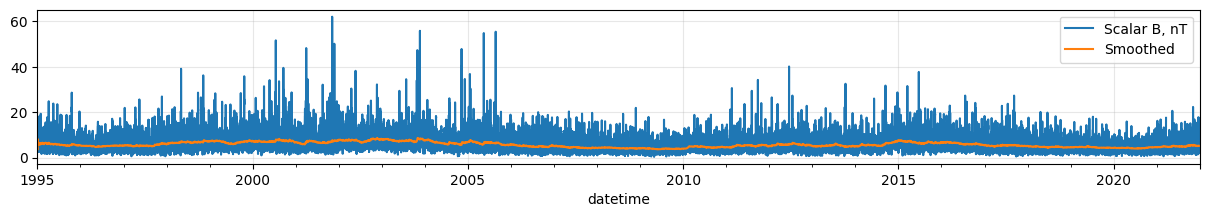

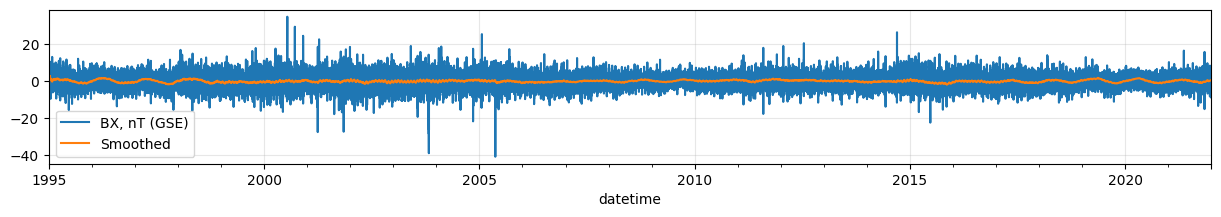

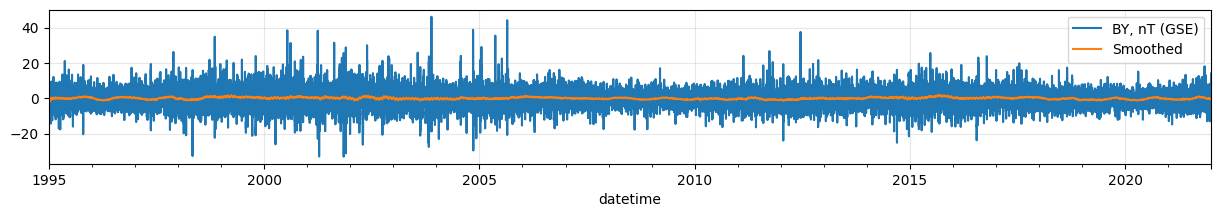

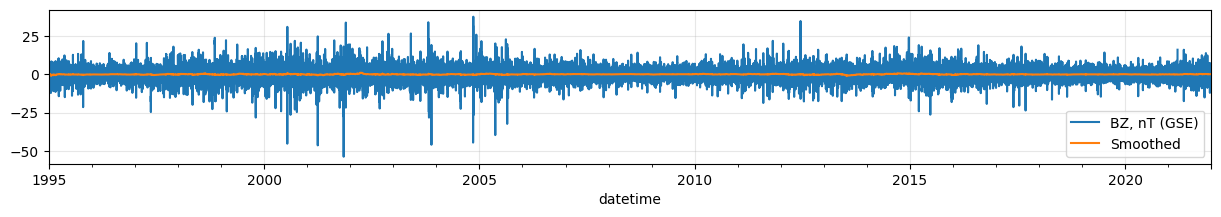

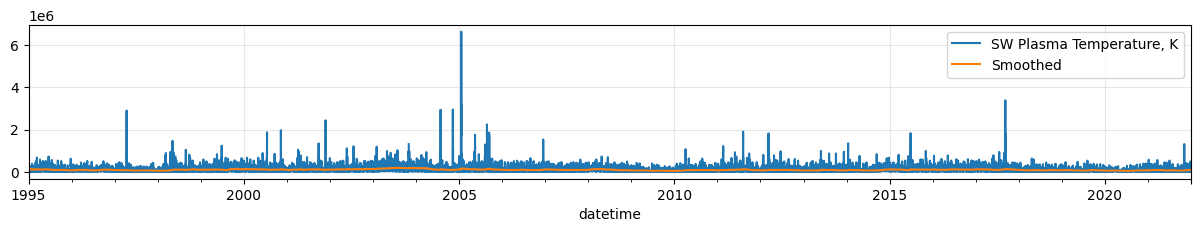

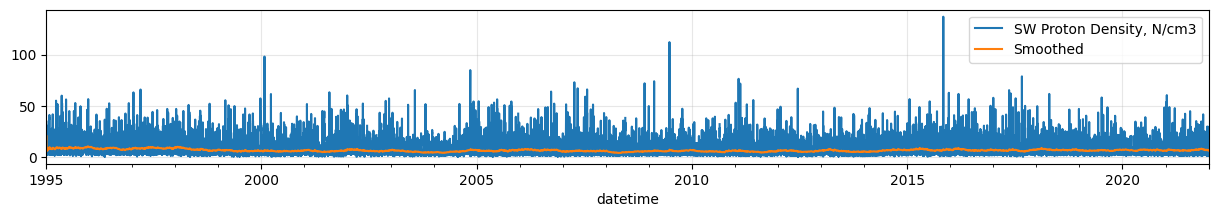

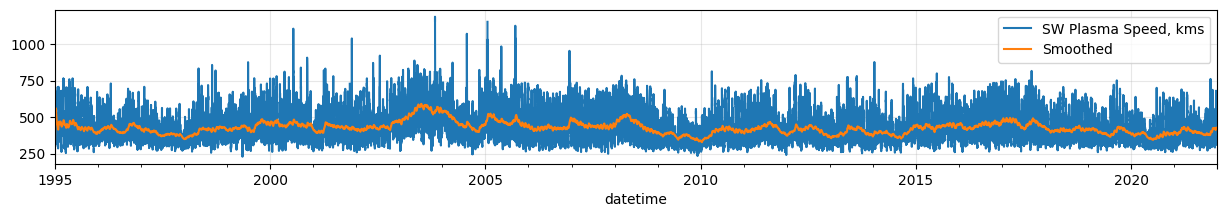

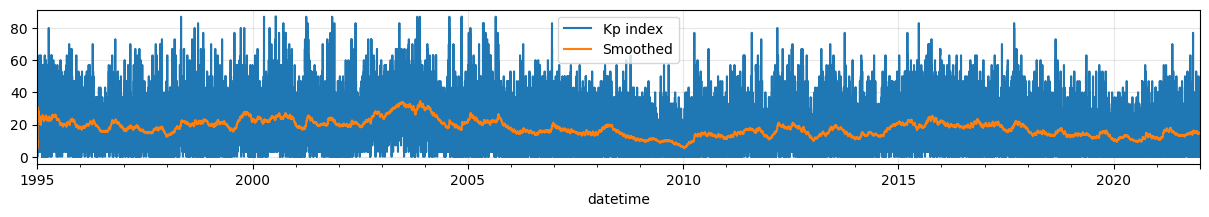

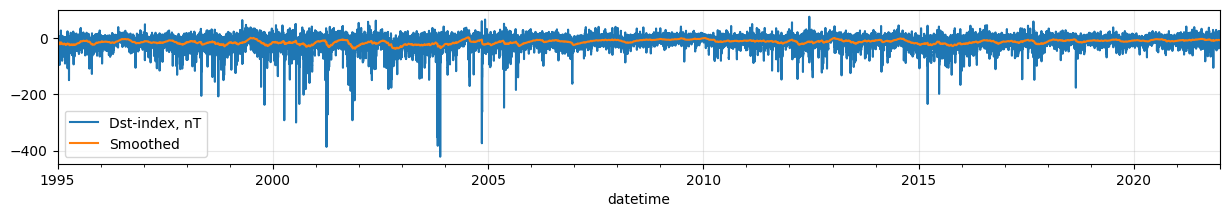

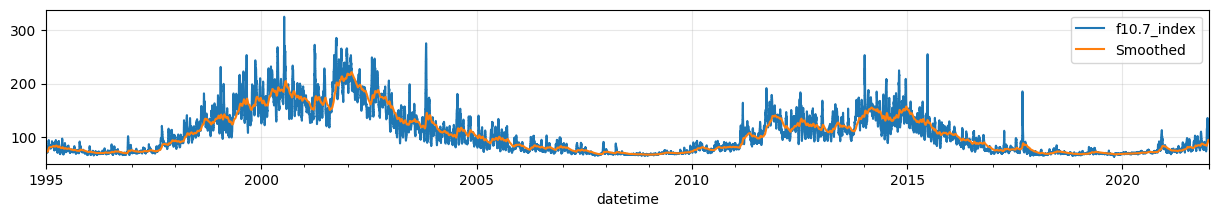

In [12]:
for i in omni_clean.columns:
    omni_clean[i].plot(figsize=(15,2))
    omni_clean[i].ewm(alpha=0.001).mean().plot(figsize=(15,2),label="Smoothed")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

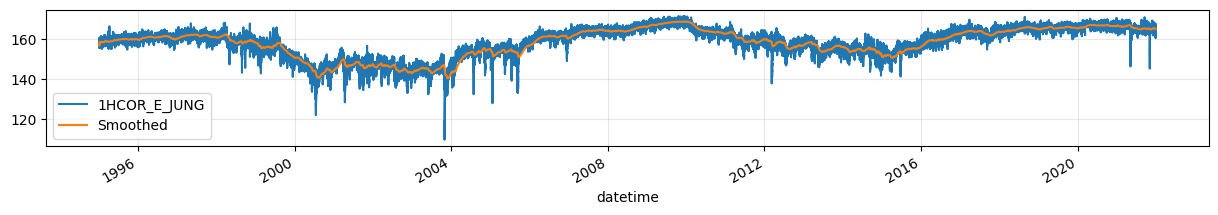

In [13]:
jung_clean["1HCOR_E_JUNG"].plot(figsize=(15,2))
jung_clean["1HCOR_E_JUNG"].ewm(alpha=0.001).mean().plot(figsize=(15,2),label="Smoothed")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
for i,j in zip(["OMNI","JUNG","FEID"],[omni_clean,jung_clean,feid_clean]):
    print("lenght of {} dataset = {}".format(i,len(j)))
    print("Columns of {} dataset = {}".format(i,j.columns))
    print(j.head())

lenght of OMNI dataset = 236688
Columns of OMNI dataset = Index(['Scalar B, nT', 'BX, nT (GSE)', 'BY, nT (GSE)', 'BZ, nT (GSE)',
       'SW Plasma Temperature, K', 'SW Proton Density, N/cm3',
       'SW Plasma Speed, kms', 'Kp index', 'Dst-index, nT', 'f10.7_index'],
      dtype='object')
                     Scalar B, nT  BX, nT (GSE)  BY, nT (GSE)  BZ, nT (GSE)  \
datetime                                                                      
1995-01-01 00:00:00           4.0          -0.6           3.2          -2.1   
1995-01-01 01:00:00           3.0          -0.9           2.4          -1.3   
1995-01-01 02:00:00           3.2           0.5           1.8          -0.4   
1995-01-01 03:00:00           4.3          -3.2           2.5           0.3   
1995-01-01 04:00:00           4.8          -4.3           2.1           0.3   

                     SW Plasma Temperature, K  SW Proton Density, N/cm3  \
datetime                                                                  
1995-0

# Comparisons between classical and quantum kernels...

In [15]:
omni_clean

,"Scalar B, nT","BX, nT (GSE)","BY, nT (GSE)","BZ, nT (GSE)","SW Plasma Temperature, K","SW Proton Density, N/cm3","SW Plasma Speed, kms",Kp index,"Dst-index, nT",f10.7_index
datetime,,,,,,,,,,
1995-01-01 00:00:00,4.0,-0.6,3.2,-2.1,15816.0,16.3,315.0,10.0,-2,72.9
1995-01-01 01:00:00,3.0,-0.9,2.4,-1.3,15601.0,18.8,315.0,10.0,3,72.9
1995-01-01 02:00:00,3.2,0.5,1.8,-0.4,20703.0,19.3,320.0,10.0,6,72.9
1995-01-01 03:00:00,4.3,-3.2,2.5,0.3,25094.0,16.4,317.0,0.0,5,72.9
1995-01-01 04:00:00,4.8,-4.3,2.1,0.3,25604.0,14.5,313.0,0.0,3,72.9
...,...,...,...,...,...,...,...,...,...,...
2021-12-31 19:00:00,5.5,1.7,2.7,4.0,80077.0,8.4,426.0,7.0,7,98.2
2021-12-31 20:00:00,4.9,0.6,2.5,3.9,78906.0,7.8,418.0,7.0,7,98.2
2021-12-31 21:00:00,5.1,1.3,2.8,3.1,88405.0,8.6,423.0,10.0,11,98.2


In [16]:
omni_clean.to_pickle("omni_clean.pkl")
feid_clean.to_pickle("feid_clean.pkl")
jung_clean.to_pickle("jung_clean.pkl")

In [17]:
for i,j in zip(["OMNI","JUNG","FEID"],[omni_clean,jung_clean,feid_clean]):
    print("lenght of {} dataset = {}".format(i,len(j)))
    print("Dataset of {} spam from {} to {}".format(i,j.index.min(),j.index.max()))
    print("Columns of {} dataset = {}".format(i,j.columns))

lenght of OMNI dataset = 236688
Dataset of OMNI spam from 1995-01-01 00:00:00 to 2021-12-31 23:00:00
Columns of OMNI dataset = Index(['Scalar B, nT', 'BX, nT (GSE)', 'BY, nT (GSE)', 'BZ, nT (GSE)',
       'SW Plasma Temperature, K', 'SW Proton Density, N/cm3',
       'SW Plasma Speed, kms', 'Kp index', 'Dst-index, nT', 'f10.7_index'],
      dtype='object')
lenght of JUNG dataset = 235277
Dataset of JUNG spam from 1995-01-01 00:00:00 to 2021-12-31 23:00:00
Columns of JUNG dataset = Index(['1HCOR_E_JUNG'], dtype='object')
lenght of FEID dataset = 2981
Dataset of FEID spam from 1995-01-01 19:40:00 to 2020-04-30 12:00:00
Columns of FEID dataset = Index(['OType', 'Hpart', 'Vpart', 'THMax', 'TVMax', 'Range', 'A10', 'Magn',
       'TDMin', 'DMin', 'MagnM', 'TDmax', 'IFilter', 'Tmin', 'Tmax', 'Vmean',
       'DMax', 'Taft', 'AFilter', 'H2sum', 'RBulk', 'TFrom', 'Kpmax', 'Tbef',
       'Txymax', 'Pxym', 'Axm', 'Axym', 'Aym', 'Var2', 'Azrange'],
      dtype='object')
